# Student Dropout Prediction

## Notebook 03 : Model Building & Evaluation

### Objective

This notebook focuses on building, training, evaluating, and comparing multiple machine learning models for student dropout prediction using the engineered dataset created in Notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/final_dataset.csv")
df.head()

,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,elluminate_clicks,wiki_clicks,page_clicks,questionnaire_clicks,quiz_clicks,repeat_activity_clicks,resource_clicks,shared_subpage_clicks,subpage_clicks,url_clicks
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,...,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,32.0,5.0
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,...,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,87.0,48.0
2,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,22.0,4.0
3,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,...,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,144.0,90.0
4,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,...,0.0,0.0,0.0,0.0,0.0,0.0,45.0,0.0,79.0,14.0


In [3]:
df.isnull().sum().sum()

np.int64(0)

In [4]:
X = df.drop("dropout", axis=1)
y = df["dropout"]

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(26038, 45)
(6510, 45)
dropout
0    0.689185
1    0.310815
Name: proportion, dtype: float64
dropout
0    0.689094
1    0.310906
Name: proportion, dtype: float64


In [8]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape)
print(X_test.shape)

(26038, 76)
(6510, 76)


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression (Baseline Model)

Logistic Regression is selected as the baseline model because it is simple, interpretable, and provides a strong benchmark for binary classification problems.

In [10]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8634408602150537
Precision: 0.7633410672853829
Recall   : 0.8127470355731226
F1 Score : 0.7872696817420436
ROC-AUC  : 0.9406326049069655


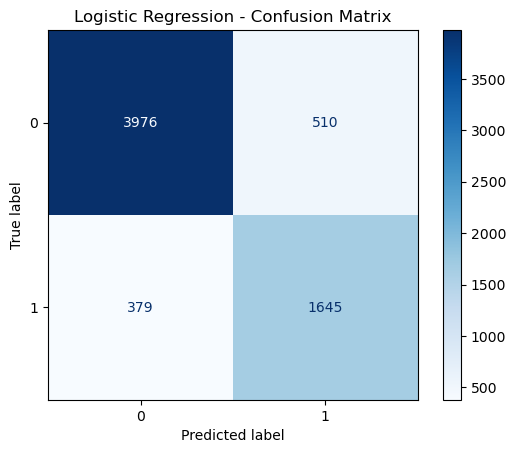

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Decision Tree Classifier

Decision Tree is a tree-based supervised learning algorithm that recursively splits the data based on feature values to classify students as dropout or non-dropout.

Unlike Logistic Regression, Decision Trees do not require feature scaling because they make decisions based on threshold values rather than distances.

In [14]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 0.8348694316436251
Precision: 0.7400101163378857
Recall   : 0.7228260869565217
F1 Score : 0.7313171707073232
ROC-AUC  : 0.8041236988505301


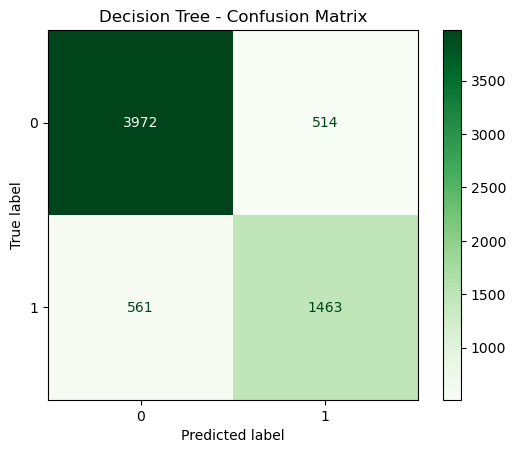

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

### Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction performance.

Instead of relying on a single tree, Random Forest trains many trees on different subsets of the data and combines their predictions using majority voting. This reduces overfitting and improves generalization.

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8729646697388633
Precision: 0.7706919945725916
Recall   : 0.841897233201581
F1 Score : 0.8047225501770956
ROC-AUC  : 0.9482610259586699


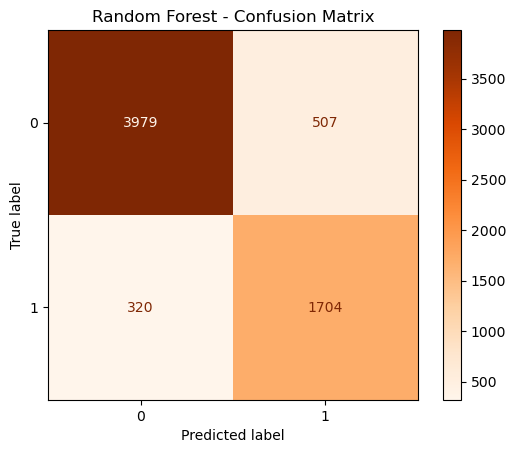

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Oranges")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
# Store results of all models
results = []
def evaluate_model(model_name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print("="*50)
    print(model_name)
    print("="*50)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    # Save results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

### XGBoost Classifier

XGBoost is a gradient boosting algorithm that builds trees sequentially. Each new tree tries to correct the mistakes made by the previous trees. It is commonly used for structured/tabular data and often performs well in classification problems.

In [24]:
import xgboost
print(xgboost.__version__)

3.3.0


In [25]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

ValueError: feature_names must be string, and may not contain [, ] or <

In [26]:
X_train.columns = (
    X_train.columns
    .str.replace("<=", "_le_", regex=False)
    .str.replace("<", "_lt_", regex=False)
    .str.replace(">", "_gt_", regex=False)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)
X_test.columns = X_train.columns

In [27]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [28]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


XGBoost
Accuracy : 0.8716
Precision: 0.7776
Recall   : 0.8221
F1 Score : 0.7992
ROC-AUC  : 0.9497


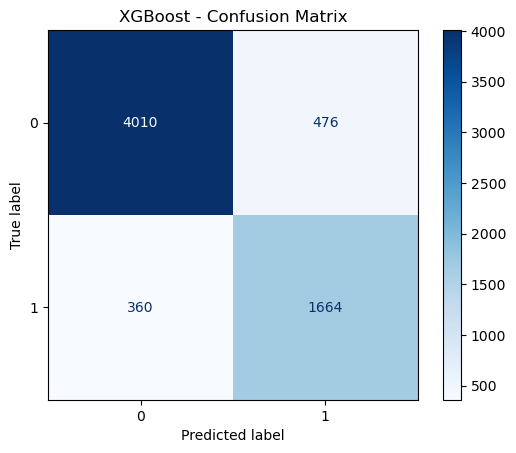

In [29]:
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

### Key Findings

- Logistic Regression established a strong baseline.
- Decision Tree suffered from overfitting and lower generalization.
- Random Forest achieved the highest Recall and F1-score.
- XGBoost achieved the highest ROC-AUC and Precision.
- The close performance of Random Forest and XGBoost suggests that feature engineering contributed significantly to the model performance.

In [30]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.8634,
        0.8349,
        0.8730,
        0.8716
    ],
    "Precision": [
        0.7633,
        0.7400,
        0.7707,
        0.7776
    ],
    "Recall": [
        0.8127,
        0.7228,
        0.8419,
        0.8221
    ],
    "F1 Score": [
        0.7873,
        0.7313,
        0.8047,
        0.7992
    ],
    "ROC-AUC": [
        0.9406,
        0.8041,
        0.9483,
        0.9497
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8634,0.7633,0.8127,0.7873,0.9406
1,Decision Tree,0.8349,0.7400,0.7228,0.7313,0.8041
2,Random Forest,0.8730,0.7707,0.8419,0.8047,0.9483
3,XGBoost,0.8716,0.7776,0.8221,0.7992,0.9497


### Hyperparameter Tuning - Random Forest

Random Forest achieved the best Recall among the baseline models. Therefore, it is selected for hyperparameter tuning to further improve its ability to identify students who are likely to drop out.

In [31]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

In [32]:
grid_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [33]:
print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [34]:
print("\nBest Cross Validation Recall:")
print(grid_rf.best_score_)


Best Cross Validation Recall:
0.8692689027318515


Tuned Random Forest
Accuracy : 0.8759
Precision: 0.7607
Recall   : 0.8765
F1 Score : 0.8145
ROC-AUC  : 0.9494


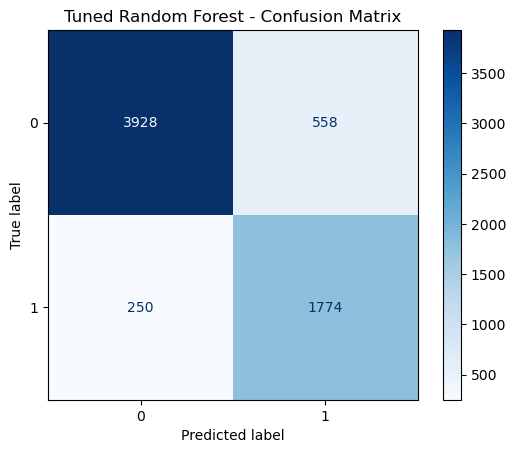

In [35]:
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]
evaluate_model(
    "Tuned Random Forest",
    y_test,
    y_pred_best_rf,
    y_prob_best_rf
)

### Observation

Hyperparameter tuning improved the Random Forest model significantly.

- Recall increased from **84.19%** to **87.65%**, allowing the model to identify more students who are likely to drop out.
- F1-score also improved, indicating a better balance between Precision and Recall.
- Although Precision decreased slightly, the improvement in Recall aligns with the primary objective of this project, making the tuned Random Forest model a stronger candidate for deployment.

In [37]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)
print("Cross Validation Recall Scores:")
print(cv_scores)
print("\nMean Recall:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Recall Scores:
[0.8721433  0.86534898 0.87708462 0.87144623 0.86032138]

Mean Recall: 0.8692689027318515
Standard Deviation: 0.005822580418546577


## Feature Importance

Random Forest provides feature importance scores that indicate the contribution of each feature to the prediction process.

Understanding the most influential features helps interpret the model and provides insights into the factors associated with student dropout.

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
16,last_activity_day,0.198968
9,average_submission_day,0.162440
6,total_assessments,0.095277
8,total_weight,0.084896
3,average_score,0.048637
4,max_score,0.045162
13,active_days,0.043098
10,total_clicks,0.036537
5,min_score,0.027659
7,average_weight,0.027195


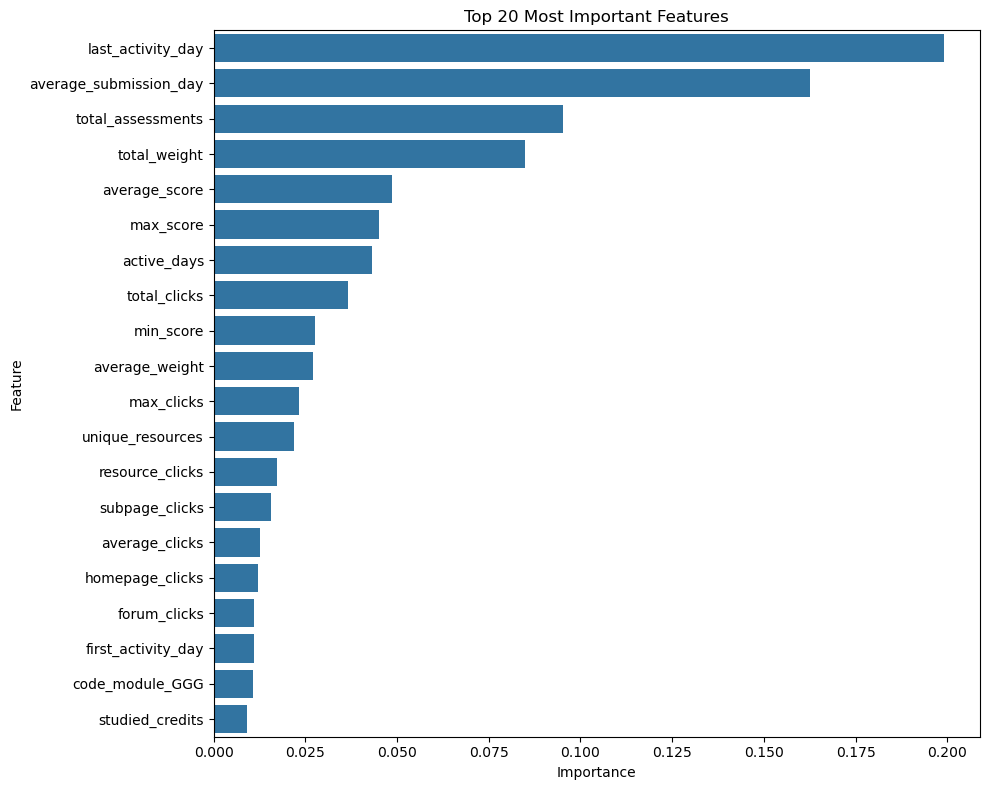

In [39]:
plt.figure(figsize=(10,8))

top20 = feature_importance.head(20)

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning - XGBoost

To ensure a fair comparison with the tuned Random Forest model, hyperparameter tuning is also performed on XGBoost using GridSearchCV.

The tuning process aims to maximize Recall, which is the primary evaluation metric for this student dropout prediction problem.

In [41]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

In [42]:
from sklearn.model_selection import GridSearchCV
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [43]:
print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
0.8889163830929224


Tuned XGBoost
Accuracy : 0.8690
Precision: 0.7379
Recall   : 0.8972
F1 Score : 0.8098
ROC-AUC  : 0.9458


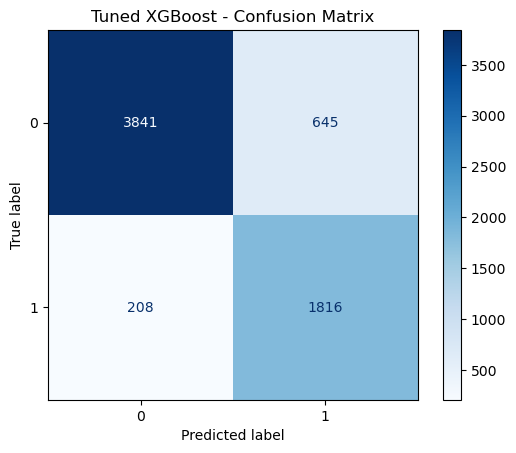

In [44]:
best_xgb = grid_xgb.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]
evaluate_model(
    "Tuned XGBoost",
    y_test,
    y_pred_best_xgb,
    y_prob_best_xgb
)

## Final Model Selection

Six experiments were conducted, including baseline models and tuned ensemble models.

Among all the evaluated models, the **Tuned XGBoost Classifier** was selected as the final model.

### Reason for Selection

Although the Tuned Random Forest achieved slightly higher Accuracy, the Tuned XGBoost achieved the highest Recall (**89.72%**).

Since the primary objective of this project is to identify students who are at risk of dropping out, Recall was considered the most important evaluation metric. A higher Recall reduces the number of at-risk students that are missed, allowing earlier academic intervention.

Therefore, the Tuned XGBoost model was selected as the final model for deployment.

In [45]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
16,last_activity_day,0.499709
9,average_submission_day,0.091228
38,code_module_CCC,0.042799
8,total_weight,0.041708
15,first_activity_day,0.040384
23,homepage_clicks,0.035022
42,code_module_GGG,0.034250
45,code_presentation_2014J,0.033363
7,average_weight,0.025034
13,active_days,0.024469


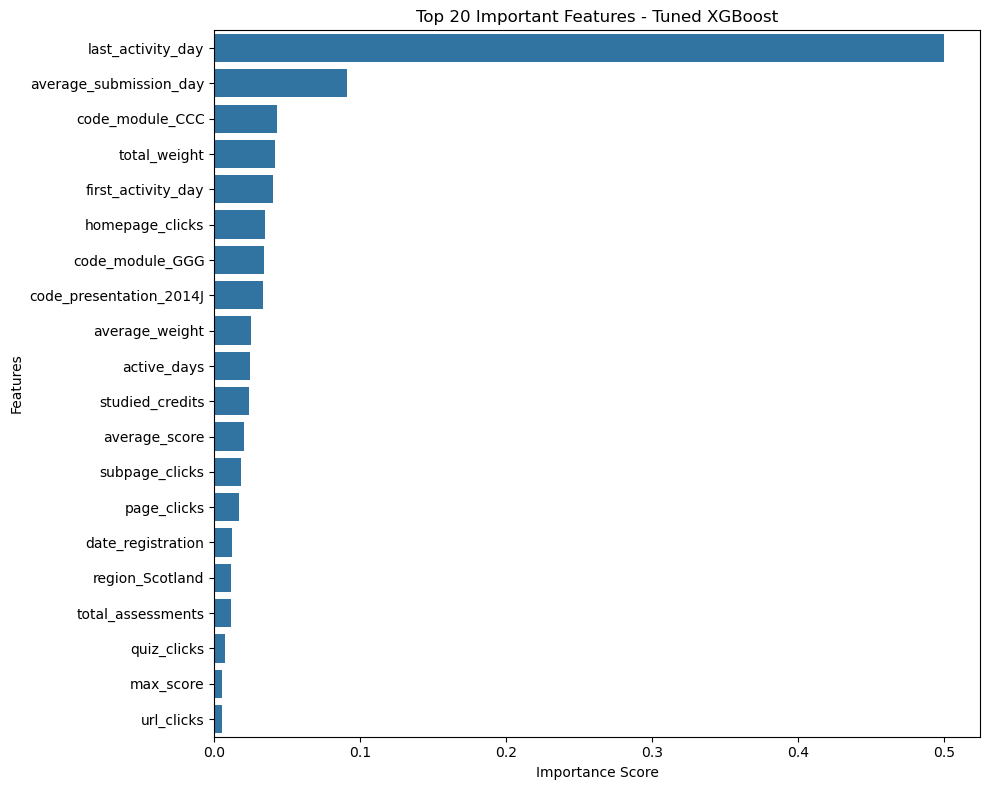

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features - Tuned XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [47]:
import joblib
joblib.dump(best_xgb, "student_dropout_xgboost.pkl")
print("Model saved successfully!")

Model saved successfully!


In [48]:
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']